# Model IndoBERTweet-LoRA

Eksperimen empiris, simulasi, dan class weight IndoBERTweet-LoRA.


In [ ]:
# Jalankan 01_preprocessing.ipynb terlebih dahulu.
import pickle
import pandas as pd

data_new = pd.read_pickle("data_preprocessed_with_emoticon.pkl")
with open("split_data.pkl", "rb") as file:
    split_data = pickle.load(file)

X_train_lstm = split_data["X_train_lstm"]
X_test_lstm = split_data["X_test_lstm"]
X_train_bert = split_data["X_train_bert"]
X_test_bert = split_data["X_test_bert"]
y_train = split_data["y_train"]
y_test = split_data["y_test"]


#BAGIAN 4 — Data Empiris IndoBERTweet-LoRA

In [ ]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [ ]:
# =====================================================
# 2. SET SEED
# =====================================================

seed = 42

set_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("GPU tersedia:", torch.cuda.is_available())

GPU tersedia: True


In [ ]:
# =====================================================
# 6. SPLIT DATA 80:20
# =====================================================
# Test set disimpan untuk evaluasi akhir.

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_bert,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

print("Distribusi train final:")
print(y_train_final.value_counts().sort_index())

print("\nDistribusi validation:")
print(y_val.value_counts().sort_index())

print("\nDistribusi test:")
print(y_test.value_counts().sort_index())

Distribusi train final:
label
0    3486
1    1055
2    1685
Name: count, dtype: int64

Distribusi validation:
label
0    388
1    117
2    187
Name: count, dtype: int64

Distribusi test:
label
0    969
1    293
2    468
Name: count, dtype: int64


In [ ]:
# =====================================================
# 8. TOKENIZER INDOBERTWEET
# =====================================================

model_name = "indolem/indobertweet-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# =====================================================
# 9. DATASET PYTORCH
# =====================================================

class SentimenDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts.tolist(),
            padding=True,
            truncation=True,
            max_length=max_length
        )
        self.labels = labels.reset_index(drop=True).values

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
# =====================================================
# 10. BUAT DATASET
# =====================================================
train_dataset = SentimenDataset(
    X_train_final,
    y_train_final,
    tokenizer_bert,
    max_length=128
)

val_dataset = SentimenDataset(
    X_val,
    y_val,
    tokenizer_bert,
    max_length=128
)

test_dataset = SentimenDataset(
    X_test_bert,
    y_test,
    tokenizer_bert,
    max_length=128
)

In [ ]:
# =====================================================
# 11. METRIK EVALUASI
# =====================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [ ]:
# =====================================================
# 12. FUNGSI MEMBUAT MODEL INDOBERTWEET-LORA
# =====================================================

def build_indobertweet_lora(dropout=0.3, r=16, lora_alpha=32):

    id2label = {
        0: "negatif",
        1: "netral",
        2: "positif"
    }

    label2id = {
        "negatif": 0,
        "netral": 1,
        "positif": 2
    }

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    model.config.id2label = id2label
    model.config.label2id = label2id

    lora_config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value"],
        lora_dropout=dropout,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        modules_to_save=["classifier"]
    )

    model = get_peft_model(model, lora_config)

    return model

In [ ]:
# =====================================================
# 13. TES MODEL LORA
# =====================================================

test_model = build_indobertweet_lora(
    dropout=0.2,
    r=8,
    lora_alpha=16
)

test_model.print_trainable_parameters()

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 297,219 || all params: 110,857,734 || trainable%: 0.2681


In [ ]:
# =====================================================
# 14. HYPERPARAMETER TUNING INDOBERTWEET-LORA
# =====================================================
# Data empiris.
# Tidak memakai class weight, oversampling, undersampling, atau balancing.

param_grid = [
    {"batch_size": 16, "dropout": 0.2, "learning_rate": 5e-5, "r": 8,  "alpha": 16},
    {"batch_size": 16, "dropout": 0.2, "learning_rate": 1e-4, "r": 8,  "alpha": 16},
    {"batch_size": 16, "dropout": 0.3, "learning_rate": 1e-4, "r": 16, "alpha": 32},
    {"batch_size": 16, "dropout": 0.3, "learning_rate": 2e-4, "r": 16, "alpha": 32},
    {"batch_size": 32, "dropout": 0.2, "learning_rate": 1e-4, "r": 16, "alpha": 32},
    {"batch_size": 32, "dropout": 0.3, "learning_rate": 1e-4, "r": 16, "alpha": 32},
]

tuning_results = []

best_f1 = -1
best_params = None
best_trial = None

for i, params in enumerate(param_grid):

    print("\n=====================================================")
    print(f"Percobaan ke-{i+1}")
    print(params)
    print("=====================================================")

    set_seed(seed)

    model = build_indobertweet_lora(
        dropout=params["dropout"],
        r=params["r"],
        lora_alpha=params["alpha"]
    )

    output_dir = f"./results_indobertweet_lora_emp_trial_{i+1}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=params["learning_rate"],
        per_device_train_batch_size=params["batch_size"],
        per_device_eval_batch_size=params["batch_size"],
        num_train_epochs=5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_dir=f"./logs_trial_{i+1}",
        logging_steps=50,
        report_to="none",
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    eval_result = trainer.evaluate()

    print("Hasil validation:")
    print(eval_result)

    tuning_results.append({
        "trial": i + 1,
        "batch_size": params["batch_size"],
        "dropout": params["dropout"],
        "learning_rate": params["learning_rate"],
        "r": params["r"],
        "alpha": params["alpha"],
        "accuracy_val": eval_result["eval_accuracy"],
        "precision_macro_val": eval_result["eval_precision_macro"],
        "recall_macro_val": eval_result["eval_recall_macro"],
        "f1_macro_val": eval_result["eval_f1_macro"]
    })

    if eval_result["eval_f1_macro"] > best_f1:
        best_f1 = eval_result["eval_f1_macro"]
        best_params = params
        best_trial = i + 1

print("\n=====================================================")
print("HYPERPARAMETER TERBAIK")
print("=====================================================")
print("Trial terbaik:", best_trial)
print("Parameter terbaik:", best_params)
print("Best validation macro F1:", best_f1)


Percobaan ke-1
{'batch_size': 16, 'dropout': 0.2, 'learning_rate': 5e-05, 'r': 8, 'alpha': 16}


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[trans

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.913945,0.856299,0.617052,0.449578,0.415780,0.384060
2,0.786812,0.748569,0.679191,0.775997,0.541656,0.495951
3,0.757787,0.683929,0.715318,0.723463,0.587936,0.571706
4,0.667309,0.631810,0.754335,0.722186,0.611418,0.605635
5,0.682343,0.623851,0.760116,0.725947,0.618834,0.616177


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[trans

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.910729,0.867362,0.598266,0.435134,0.390760,0.349632
2,0.774118,0.752007,0.682081,0.777433,0.544298,0.497839
3,0.726593,0.663237,0.721098,0.666336,0.598266,0.584664
4,0.654890,0.620976,0.755780,0.701430,0.632033,0.633073
5,0.643753,0.617286,0.761561,0.708238,0.639449,0.643160


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.643753,0.617286,5,0.761561,0.708238,0.639449,0.643160


Hasil validation:
{'eval_loss': 0.6172860860824585, 'eval_accuracy': 0.7615606936416185, 'eval_precision_macro': 0.7082379762639941, 'eval_recall_macro': 0.639449493300312, 'eval_f1_macro': 0.6431602167530693}

HYPERPARAMETER TERBAIK
Trial terbaik: 4
Parameter terbaik: {'batch_size': 16, 'dropout': 0.3, 'learning_rate': 0.0002, 'r': 16, 'alpha': 32}
Best validation macro F1: 0.7233136773907489


In [ ]:
#SIMPAN HASIL TUNING

df_tuning = pd.DataFrame(tuning_results)
df_tuning = df_tuning.sort_values(by="f1_macro_val", ascending=False)

print(df_tuning)

df_tuning.to_csv("hasil_tuning_indobertweet_lora_empiris.csv", index=False)

   trial  batch_size  dropout  learning_rate   r  alpha  accuracy_val  \
3      4          16      0.3        0.00020  16     32      0.787572   
1      2          16      0.2        0.00010   8     16      0.784682   
4      5          32      0.2        0.00010  16     32      0.783237   
2      3          16      0.3        0.00010  16     32      0.770231   
5      6          32      0.3        0.00010  16     32      0.761561   
0      1          16      0.2        0.00005   8     16      0.760116   

   precision_macro_val  recall_macro_val  f1_macro_val  
3             0.737580          0.713544      0.723314  
1             0.728025          0.696973      0.708090  
4             0.729297          0.692134      0.704234  
2             0.710843          0.672463      0.682233  
5             0.708238          0.639449      0.643160  
0             0.725947          0.618834      0.616177  


In [ ]:
#TRAIN ULANG MODEL TERBAIK

best_params = {
    "batch_size": 16,
    "dropout": 0.3,
    "learning_rate": 0.0002,
    "r": 16,
    "alpha": 32
}

In [ ]:
set_seed(seed)

best_model = build_indobertweet_lora(
    dropout=best_params["dropout"],
    r=best_params["r"],
    lora_alpha=best_params["alpha"]
)

best_model.print_trainable_parameters()

training_args_best = TrainingArguments(
    output_dir="./best_indobertweet_lora_empiris",
    learning_rate=best_params["learning_rate"],
    per_device_train_batch_size=best_params["batch_size"],
    per_device_eval_batch_size=best_params["batch_size"],
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    save_total_limit=1
)

trainer_best = Trainer(
    model=best_model,
    args=training_args_best,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_best.train()

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.722841,0.622786,0.760116,0.726410,0.641790,0.650212
2,0.647656,0.590529,0.773121,0.715057,0.691310,0.700460


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.722841,0.622786,0.760116,0.726410,0.641790,0.650212
2,0.647656,0.590529,0.773121,0.715057,0.691310,0.700460
3,0.605732,0.590349,0.768786,0.714792,0.717514,0.715906
4,0.584345,0.568659,0.789017,0.739141,0.712270,0.722371
5,0.613440,0.571018,0.787572,0.737580,0.713544,0.723314


TrainOutput(global_step=1950, training_loss=0.6390898768107096, metrics={'train_runtime': 490.6891, 'train_samples_per_second': 63.441, 'train_steps_per_second': 3.974, 'total_flos': 1900755750841200.0, 'train_loss': 0.6390898768107096, 'epoch': 5.0})

In [ ]:
label_names = ['negatif', 'netral', 'positif']

In [ ]:
#BAGIAN 17. EVALUASI AKHIR PADA DATA TEST
preds_test = trainer_best.predict(test_dataset)

y_pred_bert_emp = np.argmax(
    preds_test.predictions,
    axis=1
)

print("\n=== CLASSIFICATION REPORT — IndoBERTweet-LoRA EMPIRIS ===")

print(classification_report(
    y_test,
    y_pred_bert_emp,
    target_names=label_names,
    zero_division=0
))


=== CLASSIFICATION REPORT — IndoBERTweet-LoRA EMPIRIS ===
              precision    recall  f1-score   support

     negatif       0.85      0.89      0.87       969
      netral       0.62      0.50      0.55       293
     positif       0.76      0.78      0.77       468

    accuracy                           0.80      1730
   macro avg       0.75      0.73      0.73      1730
weighted avg       0.79      0.80      0.79      1730



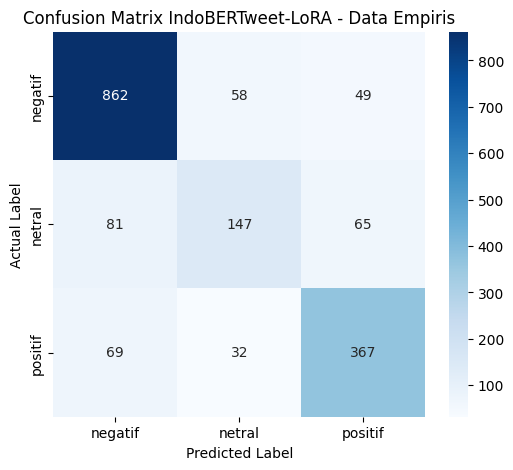

In [ ]:
#BAGIAN 18. CONFUSION MATRIX
cm_bert_emp = confusion_matrix(
    y_test,
    y_pred_bert_emp
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bert_emp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix IndoBERTweet-LoRA - Data Empiris")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
#BAGIAN 19. CEK DISTRIBUSI PREDIKSI
print("Distribusi prediksi model:")
print(pd.Series(y_pred_bert_emp).value_counts().sort_index())

print("\nDistribusi aktual:")
print(y_test.value_counts().sort_index())

Distribusi prediksi model:
0    1012
1     237
2     481
Name: count, dtype: int64

Distribusi aktual:
label
0    969
1    293
2    468
Name: count, dtype: int64


In [ ]:
#BAGIAN 20. RINGKASAN METRIK TEST
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred_bert_emp,
    average='macro',
    zero_division=0
)

accuracy = accuracy_score(
    y_test,
    y_pred_bert_emp
)

hasil_bert_emp = pd.DataFrame({
    "Model": ["IndoBERTweet-LoRA"],
    "Data": ["Empiris"],
    "Accuracy": [accuracy],
    "Precision Macro": [precision_macro],
    "Recall Macro": [recall_macro],
    "Macro F1": [f1_macro]
})

print(hasil_bert_emp)

hasil_bert_emp.to_csv("hasil_indobertweet_lora_empiris_with_emoticon.csv", index=False)

               Model     Data  Accuracy  Precision Macro  Recall Macro  \
0  IndoBERTweet-LoRA  Empiris  0.795376         0.745009      0.725157   

   Macro F1  
0   0.73281  


In [ ]:
#BAGIAN 21. SIMPAN PREDIKSI DATA TEST
hasil_prediksi_test = pd.DataFrame({
    "text": X_test_bert.reset_index(drop=True),
    "label_aktual": y_test.reset_index(drop=True),
    "sentimen_aktual": y_test.reset_index(drop=True).map({
        0: "negatif",
        1: "netral",
        2: "positif"
    }),
    "label_prediksi": y_pred_bert_emp,
    "sentimen_prediksi": pd.Series(y_pred_bert_emp).map({
        0: "negatif",
        1: "netral",
        2: "positif"
    })
})

print(hasil_prediksi_test.head())

hasil_prediksi_test.to_csv("hasil_prediksi_indobertweet_lora_empiris.csv", index=False)

                                                text  label_aktual  \
0  Siklon Tropis Senyar memengaruhi cuaca ekstrem...             0   
1  Polda Aceh Hadir untuk Warga di Tengah Bencana...             2   
2  Lah, pemerintah selama ini kemana aja? Kocak!!...             0   
3  Akun komentar BANJIR BERULANG DI TAPANULI & SI...             1   
4  Agak kesentil waktu panglima provinsi Anjing b...             0   

  sentimen_aktual  label_prediksi sentimen_prediksi  
0         negatif               0           negatif  
1         positif               2           positif  
2         negatif               0           negatif  
3          netral               1            netral  
4         negatif               0           negatif  


#BAGIAN 6 — Data Simulasi IndoBERTweet-LoRA

In [ ]:
import pandas as pd
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [ ]:
seed = 42

set_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("GPU tersedia:", torch.cuda.is_available())

GPU tersedia: True


In [ ]:
# =====================================================
# 1. GABUNGKAN DATA TRAIN BERT
# =====================================================

train_df_bert = pd.DataFrame({
    'text': X_train_bert.reset_index(drop=True),
    'label': y_train.reset_index(drop=True)
})

print("Distribusi data train BERT:")
print(train_df_bert['label'].value_counts().sort_index())

print("\nKeterangan label:")
print("0 = negatif")
print("1 = netral")
print("2 = positif")

Distribusi data train BERT:
label
0    3874
1    1172
2    1872
Name: count, dtype: int64

Keterangan label:
0 = negatif
1 = netral
2 = positif


In [ ]:
# =====================================================
# 2. HITUNG JUMLAH SKENARIO BERDASARKAN DATA TRAIN
# =====================================================
# Rasio mengikuti kondisi empiris:
# negatif = mayoritas
# positif = sedang
# netral = minoritas
#
# Jadi:
# 6:3:1 = negatif : positif : netral
# 8:1:1 = negatif : positif : netral

train_counts_bert = train_df_bert['label'].value_counts().sort_index()

n_neg = train_counts_bert[0]
n_net = train_counts_bert[1]
n_pos = train_counts_bert[2]

print("Jumlah data train:")
print("Negatif:", n_neg)
print("Netral :", n_net)
print("Positif:", n_pos)

# =====================================================
# Skenario 1:1:1
# =====================================================

base_111 = min(n_neg, n_net, n_pos)

n_111_neg = base_111
n_111_net = base_111
n_111_pos = base_111

# =====================================================
# Skenario 6:3:1
# Rasio substantif: negatif : positif : netral
# =====================================================

base_631 = min(
    n_neg // 6,
    n_pos // 3,
    n_net // 1
)

n_631_neg = 6 * base_631
n_631_pos = 3 * base_631
n_631_net = 1 * base_631

# =====================================================
# Skenario 8:1:1
# Rasio substantif: negatif : positif : netral
# =====================================================

base_811 = min(
    n_neg // 8,
    n_pos // 1,
    n_net // 1
)

n_811_neg = 8 * base_811
n_811_pos = 1 * base_811
n_811_net = 1 * base_811

print("\n=== JUMLAH DATA SIMULASI ===")

print("\nSkenario 1:1:1")
print("Negatif:", n_111_neg)
print("Netral :", n_111_net)
print("Positif:", n_111_pos)
print("Total  :", n_111_neg + n_111_net + n_111_pos)

print("\nSkenario 6:3:1")
print("Negatif:", n_631_neg)
print("Netral :", n_631_net)
print("Positif:", n_631_pos)
print("Total  :", n_631_neg + n_631_net + n_631_pos)

print("\nSkenario 8:1:1")
print("Negatif:", n_811_neg)
print("Netral :", n_811_net)
print("Positif:", n_811_pos)
print("Total  :", n_811_neg + n_811_net + n_811_pos)

Jumlah data train:
Negatif: 3874
Netral : 1172
Positif: 1872

=== JUMLAH DATA SIMULASI ===

Skenario 1:1:1
Negatif: 1172
Netral : 1172
Positif: 1172
Total  : 3516

Skenario 6:3:1
Negatif: 3744
Netral : 624
Positif: 1872
Total  : 6240

Skenario 8:1:1
Negatif: 3872
Netral : 484
Positif: 484
Total  : 4840


In [ ]:
# =====================================================
# 3. FUNGSI MEMBUAT SKENARIO
# =====================================================

def buat_skenario_bert(df, n_neg, n_net, n_pos, random_state=42):

    neg = df[df['label'] == 0].sample(
        n=n_neg,
        random_state=random_state,
        replace=False
    )

    net = df[df['label'] == 1].sample(
        n=n_net,
        random_state=random_state,
        replace=False
    )

    pos = df[df['label'] == 2].sample(
        n=n_pos,
        random_state=random_state,
        replace=False
    )

    result = pd.concat([neg, net, pos])

    result = result.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return result

In [ ]:
# =====================================================
# 4. MEMBUAT DATA SIMULASI
# =====================================================

skenario_bert_111 = buat_skenario_bert(
    train_df_bert,
    n_neg=n_111_neg,
    n_net=n_111_net,
    n_pos=n_111_pos,
    random_state=42
)

skenario_bert_631 = buat_skenario_bert(
    train_df_bert,
    n_neg=n_631_neg,
    n_net=n_631_net,
    n_pos=n_631_pos,
    random_state=42
)

skenario_bert_811 = buat_skenario_bert(
    train_df_bert,
    n_neg=n_811_neg,
    n_net=n_811_net,
    n_pos=n_811_pos,
    random_state=42
)

In [ ]:
# =====================================================
# 5. CEK DISTRIBUSI SKENARIO
# =====================================================

print("=== SKENARIO 1:1:1 ===")
print(skenario_bert_111['label'].value_counts().sort_index())

print("\n=== SKENARIO 6:3:1 ===")
print(skenario_bert_631['label'].value_counts().sort_index())

print("\n=== SKENARIO 8:1:1 ===")
print(skenario_bert_811['label'].value_counts().sort_index())

=== SKENARIO 1:1:1 ===
label
0    1172
1    1172
2    1172
Name: count, dtype: int64

=== SKENARIO 6:3:1 ===
label
0    3744
1     624
2    1872
Name: count, dtype: int64

=== SKENARIO 8:1:1 ===
label
0    3872
1     484
2     484
Name: count, dtype: int64


In [ ]:
#Tokenizer IndoBERTweet
model_name = "indolem/indobertweet-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# =====================================================
# 6. DATASET PYTORCH
# =====================================================

class SentimenDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts.tolist(),
            padding=True,
            truncation=True,
            max_length=max_length
        )
        self.labels = labels.reset_index(drop=True).values

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
#Dataset test empiris
test_dataset_bert_sim = SentimenDataset(
    X_test_bert,
    y_test,
    tokenizer_bert,
    max_length=128
)

In [ ]:
# =====================================================
# 9. METRIK EVALUASI
# =====================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [ ]:
#Fungsi model IndoBERTweet-LoRA
def build_indobertweet_lora(dropout=0.3, r=16, lora_alpha=32):

    id2label = {
        0: "negatif",
        1: "netral",
        2: "positif"
    }

    label2id = {
        "negatif": 0,
        "netral": 1,
        "positif": 2
    }

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    model.config.id2label = id2label
    model.config.label2id = label2id

    lora_config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value"],
        lora_dropout=dropout,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        modules_to_save=["classifier"]
    )

    model = get_peft_model(model, lora_config)

    return model

In [ ]:
# =====================================================
# 11. FUNGSI TRAINING SIMULASI INDOBERTWEET-LORA
# =====================================================

def train_indobertweet_lora_skenario(skenario_df, nama_skenario):

    print(f"\n{'='*70}")
    print(f"IndoBERTweet-LoRA - SKENARIO {nama_skenario}")
    print(f"{'='*70}")

    X_train_sim = skenario_df['text']
    y_train_sim = skenario_df['label']

    # Validation stratified dari data simulasi
    X_train_sim_final, X_val_sim, y_train_sim_final, y_val_sim = train_test_split(
        X_train_sim,
        y_train_sim,
        test_size=0.1,
        stratify=y_train_sim,
        random_state=42
    )

    print("Distribusi train simulasi final:")
    print(y_train_sim_final.value_counts().sort_index())

    print("\nDistribusi validation simulasi:")
    print(y_val_sim.value_counts().sort_index())

    train_dataset_sim = SentimenDataset(
        X_train_sim_final,
        y_train_sim_final,
        tokenizer_bert,
        max_length=128
    )

    val_dataset_sim = SentimenDataset(
        X_val_sim,
        y_val_sim,
        tokenizer_bert,
        max_length=128
    )

    set_seed(42)

    model = build_indobertweet_lora(
        dropout=0.3,
        r=16,
        lora_alpha=32
    )

    model.print_trainable_parameters()

    training_args = TrainingArguments(
        output_dir=f"./results_indobertweet_lora_sim_{nama_skenario.replace(':', '_')}",
        learning_rate=0.0002,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset_sim,
        eval_dataset=val_dataset_sim,
        compute_metrics=compute_metrics
    )

    trainer.train()

    preds_test = trainer.predict(test_dataset_bert_sim)

    y_pred = np.argmax(
        preds_test.predictions,
        axis=1
    )

    label_names = ['negatif', 'netral', 'positif']

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f"Confusion Matrix IndoBERTweet-LoRA - Skenario {nama_skenario}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    hasil = {
        "Skenario": nama_skenario,
        "Model": "IndoBERTweet-LoRA",
        "Accuracy": accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "Macro F1": f1_macro
    }

    return hasil, y_pred, cm


IndoBERTweet-LoRA - SKENARIO 1:1:1
Distribusi train simulasi final:
label
0    1055
1    1055
2    1054
Name: count, dtype: int64

Distribusi validation simulasi:
label
0    117
1    117
2    118
Name: count, dtype: int64


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.025472,0.884149,0.602273,0.606901,0.601912,0.590206
2,0.867793,0.801369,0.656250,0.656654,0.655923,0.653154
3,0.744126,0.777070,0.656250,0.655889,0.655971,0.654016
4,0.700753,0.779249,0.670455,0.674298,0.670071,0.667607
5,0.679492,0.769220,0.664773,0.666467,0.664566,0.664260



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.88      0.72      0.79       969
      netral       0.46      0.58      0.52       293
     positif       0.69      0.84      0.76       468

    accuracy                           0.73      1730
   macro avg       0.68      0.71      0.69      1730
weighted avg       0.76      0.73      0.74      1730



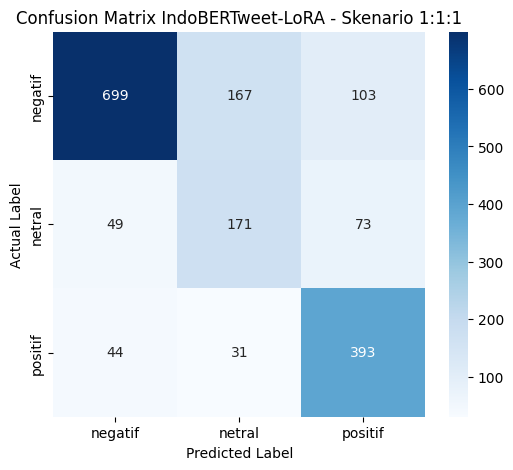

In [ ]:
# =====================================================
# 12. TRAINING SKENARIO 1:1:1
# =====================================================

hasil_bert_111, y_pred_bert_111, cm_bert_111 = train_indobertweet_lora_skenario(
    skenario_bert_111,
    "1:1:1"
)


IndoBERTweet-LoRA - SKENARIO 6:3:1
Distribusi train simulasi final:
label
0    3369
1     562
2    1685
Name: count, dtype: int64

Distribusi validation simulasi:
label
0    375
1     62
2    187
Name: count, dtype: int64


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.656625,0.602669,0.780449,0.508503,0.566935,0.536099
2,0.511157,0.568026,0.799679,0.759769,0.602720,0.595670
3,0.521025,0.560234,0.798077,0.700811,0.636837,0.645974
4,0.547808,0.544370,0.801282,0.702669,0.658371,0.670947
5,0.525681,0.544330,0.801282,0.698317,0.654778,0.666396



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.84      0.92      0.88       969
      netral       0.74      0.37      0.49       293
     positif       0.74      0.82      0.78       468

    accuracy                           0.80      1730
   macro avg       0.77      0.70      0.72      1730
weighted avg       0.80      0.80      0.79      1730



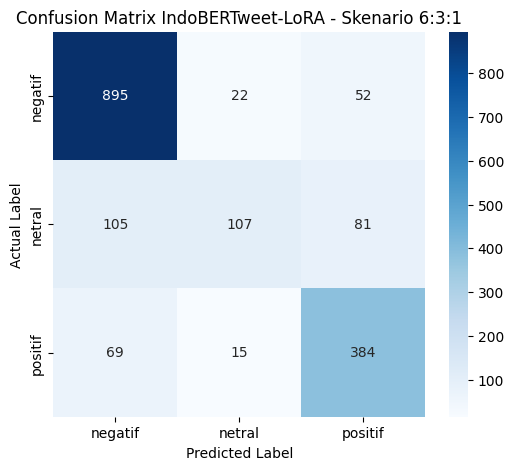

In [ ]:
# =====================================================
# 13. TRAINING SKENARIO 6:3:1
# =====================================================

hasil_bert_631, y_pred_bert_631, cm_bert_631 = train_indobertweet_lora_skenario(
    skenario_bert_631,
    "6:3:1"
)


IndoBERTweet-LoRA - SKENARIO 8:1:1
Distribusi train simulasi final:
label
0    3485
1     435
2     436
Name: count, dtype: int64

Distribusi validation simulasi:
label
0    387
1     49
2     48
Name: count, dtype: int64


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.583295,0.549242,0.799587,0.266529,0.333333,0.296211
2,0.477455,0.439275,0.842975,0.696525,0.526981,0.547466
3,0.431517,0.434439,0.838843,0.645040,0.597831,0.589402
4,0.422382,0.436036,0.845041,0.677432,0.588390,0.586486
5,0.436528,0.435025,0.847107,0.672330,0.595051,0.600980



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.78      0.94      0.85       969
      netral       0.66      0.20      0.31       293
     positif       0.75      0.75      0.75       468

    accuracy                           0.76      1730
   macro avg       0.73      0.63      0.64      1730
weighted avg       0.75      0.76      0.73      1730



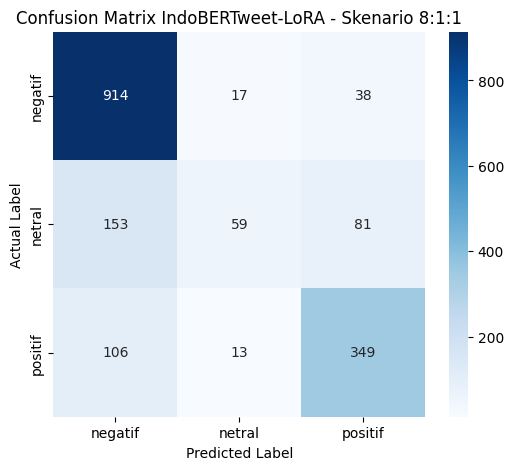

In [ ]:
# =====================================================
# 14. TRAINING SKENARIO 8:1:1
# =====================================================

hasil_bert_811, y_pred_bert_811, cm_bert_811 = train_indobertweet_lora_skenario(
    skenario_bert_811,
    "8:1:1"
)

In [ ]:
# =====================================================
# 15. RINGKASAN HASIL SIMULASI INDOBERTWEET-LORA
# =====================================================

hasil_simulasi_bert = pd.DataFrame([
    hasil_bert_111,
    hasil_bert_631,
    hasil_bert_811
])

print(hasil_simulasi_bert)

hasil_simulasi_bert.to_csv(
    "hasil_simulasi_indobertweet_lora.csv",
    index=False
)

  Skenario              Model  Accuracy  Precision Macro  Recall Macro  \
0    1:1:1  IndoBERTweet-LoRA  0.730058         0.678892      0.714908   
1    6:3:1  IndoBERTweet-LoRA  0.801156         0.774344      0.703111   
2    8:1:1  IndoBERTweet-LoRA  0.764162         0.729282      0.630111   

   Macro F1  
0  0.689480  
1  0.715903  
2  0.636012  


In [ ]:
# =====================================================
# 16. SIMPAN PREDIKSI PER SKENARIO
# =====================================================

id2label = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

prediksi_simulasi_bert = pd.DataFrame({
    "text": X_test_bert.reset_index(drop=True),
    "label_aktual": y_test.reset_index(drop=True),
    "sentimen_aktual": y_test.reset_index(drop=True).map(id2label),

    "pred_111": y_pred_bert_111,
    "sentimen_pred_111": pd.Series(y_pred_bert_111).map(id2label),

    "pred_631": y_pred_bert_631,
    "sentimen_pred_631": pd.Series(y_pred_bert_631).map(id2label),

    "pred_811": y_pred_bert_811,
    "sentimen_pred_811": pd.Series(y_pred_bert_811).map(id2label)
})

print(prediksi_simulasi_bert.head())

prediksi_simulasi_bert.to_csv(
    "prediksi_simulasi_indobertweet_lora.csv",
    index=False
)

                                                text  label_aktual  \
0  Siklon Tropis Senyar memengaruhi cuaca ekstrem...             0   
1  Polda Aceh Hadir untuk Warga di Tengah Bencana...             2   
2  Lah, pemerintah selama ini kemana aja? Kocak!!...             0   
3  Akun komentar BANJIR BERULANG DI TAPANULI & SI...             1   
4  Agak kesentil waktu panglima provinsi Anjing b...             0   

  sentimen_aktual  pred_111 sentimen_pred_111  pred_631 sentimen_pred_631  \
0         negatif         0           negatif         0           negatif   
1         positif         2           positif         2           positif   
2         negatif         0           negatif         0           negatif   
3          netral         1            netral         1            netral   
4         negatif         0           negatif         0           negatif   

   pred_811 sentimen_pred_811  
0         0           negatif  
1         0           negatif  
2         0         

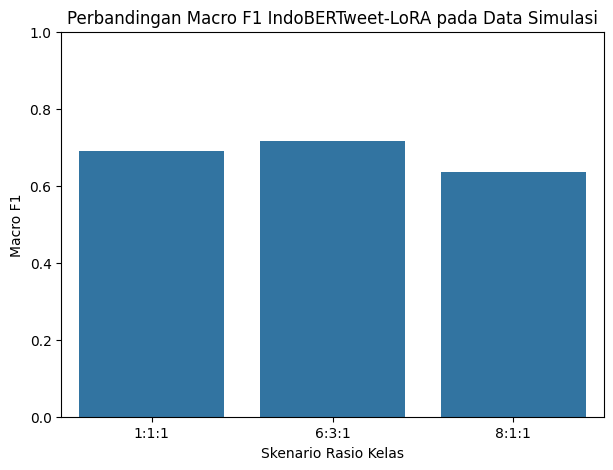

In [ ]:
# =====================================================
# 17. VISUALISASI MACRO F1 PER SKENARIO
# =====================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hasil_simulasi_bert,
    x="Skenario",
    y="Macro F1"
)

plt.title("Perbandingan Macro F1 IndoBERTweet-LoRA pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.show()

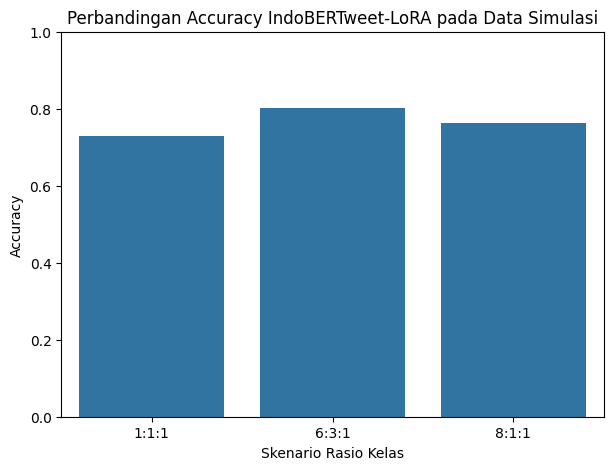

In [ ]:
# =====================================================
# 18. VISUALISASI ACCURACY PER SKENARIO
# =====================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hasil_simulasi_bert,
    x="Skenario",
    y="Accuracy"
)

plt.title("Perbandingan Accuracy IndoBERTweet-LoRA pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

#balance indobertweet

In [ ]:
#CLASS WEIGHT UNTUK IndoBERTweet-LoRA
#Import library
import numpy as np
import pandas as pd
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [ ]:
#Set seed
seed = 42

set_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("GPU tersedia:", torch.cuda.is_available())

GPU tersedia: True


In [ ]:
#Split train BERT menjadi train final dan validation
X_train_bert_final, X_val_bert, y_train_bert_final, y_val_bert = train_test_split(
    X_train_bert,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

print("Distribusi train final:")
print(y_train_bert_final.value_counts().sort_index())

print("\nDistribusi validation:")
print(y_val_bert.value_counts().sort_index())

print("\nDistribusi test:")
print(y_test.value_counts().sort_index())

Distribusi train final:
label
0    3486
1    1055
2    1685
Name: count, dtype: int64

Distribusi validation:
label
0    388
1    117
2    187
Name: count, dtype: int64

Distribusi test:
label
0    969
1    293
2    468
Name: count, dtype: int64


In [ ]:
#Hitung class weight
classes = np.array([0, 1, 2])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_bert_final
)

class_weights_tensor = torch.tensor(
    class_weights_array,
    dtype=torch.float
)

print("Class weight:")
print(class_weights_tensor)

print("\nKeterangan:")
print("0 = negatif")
print("1 = netral")
print("2 = positif")

Class weight:
tensor([0.5953, 1.9671, 1.2317])

Keterangan:
0 = negatif
1 = netral
2 = positif


In [ ]:
#Tokenizer IndoBERTweet
model_name = "indolem/indobertweet-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

In [ ]:
#Dataset PyTorch
class SentimenDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts.tolist(),
            padding=True,
            truncation=True,
            max_length=max_length
        )
        self.labels = labels.reset_index(drop=True).values

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
#Buat dataset
train_dataset_bert_cw = SentimenDataset(
    X_train_bert_final,
    y_train_bert_final,
    tokenizer_bert,
    max_length=128
)

val_dataset_bert_cw = SentimenDataset(
    X_val_bert,
    y_val_bert,
    tokenizer_bert,
    max_length=128
)

test_dataset_bert_cw = SentimenDataset(
    X_test_bert,
    y_test,
    tokenizer_bert,
    max_length=128
)

In [ ]:
#Metrik evaluasi
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [ ]:
#Fungsi model IndoBERTweet-LoRA
def build_indobertweet_lora(dropout=0.3, r=16, lora_alpha=32):

    id2label = {
        0: "negatif",
        1: "netral",
        2: "positif"
    }

    label2id = {
        "negatif": 0,
        "netral": 1,
        "positif": 2
    }

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    model.config.id2label = id2label
    model.config.label2id = label2id

    lora_config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value"],
        lora_dropout=dropout,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        modules_to_save=["classifier"]
    )

    model = get_peft_model(model, lora_config)

    return model

In [ ]:
#Custom Trainer untuk class weight
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        weights = class_weights_tensor.to(logits.device)

        loss_fct = nn.CrossEntropyLoss(weight=weights)

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [ ]:
#Training IndoBERTweet-LoRA dengan class weight
best_params = {
    "batch_size": 16,
    "dropout": 0.3,
    "learning_rate": 0.0002,
    "r": 16,
    "alpha": 32
}

set_seed(seed)

model_bert_cw = build_indobertweet_lora(
    dropout=best_params["dropout"],
    r=best_params["r"],
    lora_alpha=best_params["alpha"]
)

model_bert_cw.print_trainable_parameters()

training_args_bert_cw = TrainingArguments(
    output_dir="./indobertweet_lora_class_weight",
    learning_rate=best_params["learning_rate"],
    per_device_train_batch_size=best_params["batch_size"],
    per_device_eval_batch_size=best_params["batch_size"],
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    save_total_limit=1
)

trainer_bert_cw = WeightedTrainer(
    model=model_bert_cw,
    args=training_args_bert_cw,
    train_dataset=train_dataset_bert_cw,
    eval_dataset=val_dataset_bert_cw,
    compute_metrics=compute_metrics
)

trainer_bert_cw.train()

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.793389,0.753772,0.671965,0.636120,0.679281,0.642325
2,0.747505,0.684169,0.728324,0.680218,0.706465,0.686846
3,0.679395,0.671326,0.729769,0.684091,0.711304,0.689815
4,0.682983,0.672938,0.760116,0.708137,0.732896,0.716661
5,0.694023,0.669695,0.757225,0.707131,0.732244,0.714999


TrainOutput(global_step=1950, training_loss=0.7324357194166917, metrics={'train_runtime': 509.2682, 'train_samples_per_second': 61.127, 'train_steps_per_second': 3.829, 'total_flos': 1900755750841200.0, 'train_loss': 0.7324357194166917, 'epoch': 5.0})

In [ ]:
#Evaluasi IndoBERTweet-LoRA class weight
preds_test_cw = trainer_bert_cw.predict(test_dataset_bert_cw)

y_pred_bert_cw = np.argmax(
    preds_test_cw.predictions,
    axis=1
)

label_names = ['negatif', 'netral', 'positif']

print("\n=== CLASSIFICATION REPORT — IndoBERTweet-LoRA CLASS WEIGHT ===")

print(classification_report(
    y_test,
    y_pred_bert_cw,
    target_names=label_names,
    zero_division=0
))


=== CLASSIFICATION REPORT — IndoBERTweet-LoRA CLASS WEIGHT ===
              precision    recall  f1-score   support

     negatif       0.88      0.77      0.82       969
      netral       0.48      0.61      0.54       293
     positif       0.74      0.81      0.78       468

    accuracy                           0.75      1730
   macro avg       0.70      0.73      0.71      1730
weighted avg       0.77      0.75      0.76      1730



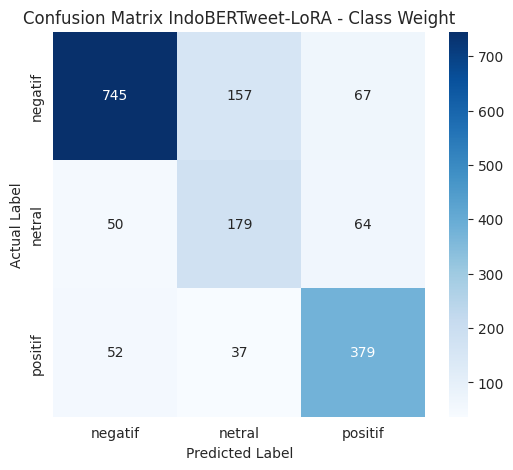

In [ ]:
#Confusion matrix IndoBERTweet-LoRA class weight
cm_bert_cw = confusion_matrix(
    y_test,
    y_pred_bert_cw
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bert_cw,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix IndoBERTweet-LoRA - Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
#Ringkasan metrik IndoBERTweet-LoRA class weight
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred_bert_cw,
    average='macro',
    zero_division=0
)

accuracy = accuracy_score(
    y_test,
    y_pred_bert_cw
)

hasil_bert_cw = pd.DataFrame({
    "Model": ["IndoBERTweet-LoRA"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [accuracy],
    "Precision Macro": [precision_macro],
    "Recall Macro": [recall_macro],
    "Macro F1": [f1_macro]
})

print(hasil_bert_cw)

hasil_bert_cw.to_csv(
    "hasil_indobertweet_lora_class_weight.csv",
    index=False
)

               Model     Perlakuan  Accuracy  Precision Macro  Recall Macro  \
0  IndoBERTweet-LoRA  Class Weight  0.753179         0.700868      0.729861   

   Macro F1  
0  0.711024  


In [ ]:
import pandas as pd

# Tabel hasil tanpa class weight
hasil_tanpa_cw = pd.DataFrame({
    "Model": ["LSTM", "IndoBERTweet-LoRA"],
    "Perlakuan": ["Tanpa Class Weight", "Tanpa Class Weight"],
    "Accuracy": [0.740, 0.800],  # sesuaikan hasil empiris
    "Precision Macro": [0.690, 0.745],
    "Recall Macro": [0.650, 0.725],
    "Macro F1": [0.660, 0.733]
})

# Tabel hasil LSTM class weight
hasil_lstm_cw = pd.DataFrame({
    "Model": ["LSTM"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [0.750],  # ganti sesuai hasil aktual
    "Precision Macro": [0.700],
    "Recall Macro": [0.690],
    "Macro F1": [0.695]
})

# Tabel hasil IndoBERTweet-LORA class weight (jika ada)
hasil_bert_cw = pd.DataFrame({
    "Model": ["IndoBERTweet-LoRA"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [0.810],  # ganti sesuai hasil aktual
    "Precision Macro": [0.740],
    "Recall Macro": [0.730],
    "Macro F1": [0.735]
})

# Gabungkan semua
hasil_class_weight = pd.concat([
    hasil_tanpa_cw,
    hasil_lstm_cw,
    hasil_bert_cw
], ignore_index=True)

print(hasil_class_weight)

# Simpan ke CSV
hasil_class_weight.to_csv("perbandingan_class_weight.csv", index=False)

               Model           Perlakuan  Accuracy  Precision Macro  \
0               LSTM  Tanpa Class Weight      0.74            0.690   
1  IndoBERTweet-LoRA  Tanpa Class Weight      0.80            0.745   
2               LSTM        Class Weight      0.75            0.700   
3  IndoBERTweet-LoRA        Class Weight      0.81            0.740   

   Recall Macro  Macro F1  
0         0.650     0.660  
1         0.725     0.733  
2         0.690     0.695  
3         0.730     0.735  
